# 26. Copulas and joint frequency

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

A reservoir cares about two things at once. The peak inflow sizes the spillway; the runoff volume
sizes the storage. Fitting each record separately says how often each is exceeded and says
nothing about how often they arrive together. A copula answers that second question: it holds the
two marginal distributions fixed and models only the dependence between them.

`corehydropy` exposes the seven bivariate copulas of the Numerics library through `Copula` and
`copula_fit()`, and the multivariate distributions through `mvdist_normal()` and its siblings.
This example fits a copula to a paired peak-and-volume record, prices a coincident design event,
and checks the answer against the model-based `bivariate_analysis()` path.

## What you'll learn

- Fit a copula's dependence parameter three ways: maximum pseudo-likelihood, Kendall's tau
  inversion, and inference from margins.
- Read tail dependence, and watch two copulas that fit the body of a sample almost equally well
  disagree about its joint tail.
- Compute the and-joint exceedance probability of a coincident peak-and-volume event, and set it
  against the answer independence would give.
- Recover the same probability from a bivariate normal, and cross-check the whole thing against
  `bivariate_analysis()`.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import corehydropy as ch

## Peak and volume pairs

Forty-eight water years. The peaks are the annual peak-flow record used in
[example 21](../21-flood-frequency/python.ipynb) and
[example 23](../23-censored-flood-frequency/python.ipynb); the volumes are a companion record
written for this example, so the page is self-contained and both languages read exactly the same
numbers.

In [2]:
peak = [
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000,
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600,
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600,
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600,
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460,
]
volume = [
    7.21, 3.21, 11.88, 10.70, 9.07, 5.31, 7.04, 5.33, 6.18, 9.54,
    9.68, 7.66, 8.99, 5.95, 5.37, 6.45, 7.00, 13.71, 12.75, 18.27,
    11.54, 8.19, 11.15, 10.35, 3.00, 5.67, 6.71, 8.47, 12.02, 12.23,
    10.71, 9.58, 9.82, 8.90, 8.80, 8.55, 8.48, 3.50, 6.60, 16.79,
    7.39, 12.95, 11.09, 7.31, 11.50, 16.79, 8.05, 8.56,
]
print(
    f"{len(peak)} water years; peak {min(peak):,} to {max(peak):,} cfs, "
    f"volume {min(volume):.2f} to {max(volume):.2f} thousand acre-feet"
)

48 water years; peak 2,700 to 22,600 cfs, volume 3.00 to 18.27 thousand acre-feet


The design event this page prices is a 20,000 cfs peak arriving with a 12 thousand acre-foot
volume.

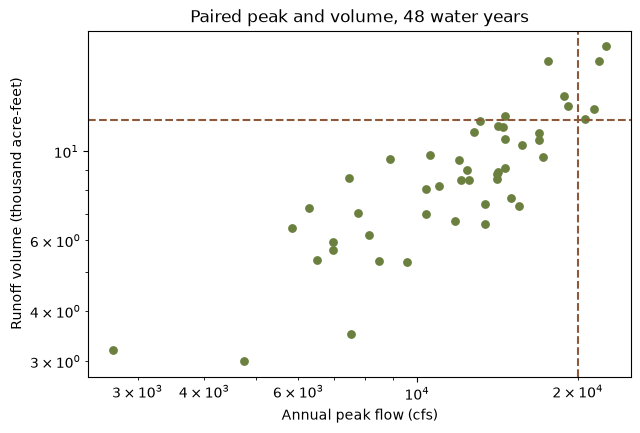

In [3]:
q_peak = 20000
q_vol = 12

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(peak, volume, s=28, color="#6b7f3f")
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(q_peak, ls="--", color="#8c5a3b")
ax.axhline(q_vol, ls="--", color="#8c5a3b")
ax.set_xlabel("Annual peak flow (cfs)")
ax.set_ylabel("Runoff volume (thousand acre-feet)")
ax.set_title("Paired peak and volume, 48 water years")
plt.show()

## Dependence without marginals

`copula_fit(family, x, y, method="mpl")` maximizes the pseudo-likelihood. That likelihood is
defined on the plotting positions `rank / (n + 1)` rather than on the data scale, so it never
touches the marginal distributions. Pass the raw paired observations: the ranking happens inside
the shared C++ core, which is why R and Python fit the same number from the same input.

In [4]:
families = ["Clayton", "Frank", "Gumbel", "Joe", "Normal"]
mpl = {f: ch.copula_fit(f, peak, volume, method="mpl") for f in families}

ranking = pd.DataFrame(
    {
        "n_parameters": [len(cop.params()) for cop in mpl.values()],
        "theta": [cop.theta for cop in mpl.values()],
        "pseudo_loglik": [
            cop.log_likelihood(peak, volume, method="pseudo") for cop in mpl.values()
        ],
    },
    index=families,
)
ranking.sort_values("pseudo_loglik", ascending=False).round(4)

,n_parameters,theta,pseudo_loglik
Normal,1,0.8652,30.3702
Gumbel,1,2.8147,30.0438
Joe,1,3.5522,26.7852
Frank,1,8.6716,25.7708
Clayton,1,2.3063,22.7077


All five carry one dependence parameter and all five are evaluated on the same pseudo
observations, so their pseudo log-likelihoods rank them directly. The ranking barely separates
the top two: the Normal copula leads, the Gumbel follows, and both stand well clear of the other
three. Both are carried forward below, because they turn out to disagree about exactly the part
of the sample the design question asks about.

`method="tau"` inverts Kendall's tau into the dependence parameter with no optimization at all.
Upstream implements that inversion for Clayton, Gumbel, and AliMikhailHaq only, so asking any
other family for it is an error rather than a silent fallback.

In [5]:
for family in ("Clayton", "Gumbel"):
    print(f"{family:<10}{ch.copula_fit(family, peak, volume, method='tau').theta:>10.4f}")

try:
    ch.copula_fit("Frank", peak, volume, method="tau")
except Exception as err:
    print(err)

Clayton       3.4473
Gumbel        2.7237
method 'tau' is not available for 'Frank'; upstream implements SetThetaFromTau for Clayton, Gumbel and AliMikhailHaq only


## Inference from margins

Inference from margins fits each marginal by maximum likelihood first, then estimates the copula
with those marginals held fixed. Naming a family in `margin_x` or `margin_y` is what asks for
that first step; passing an already-parameterized `Distribution` attaches it as given and skips
the fit. A named marginal is rejected under `"mpl"` and `"tau"`, since neither method looks at
marginals and the name would come back unfitted.

In [6]:
gumbel = ch.copula_fit("Gumbel", peak, volume, method="ifm",
                       margin_x="LogNormal", margin_y="LogNormal")
normal = ch.copula_fit("Normal", peak, volume, method="ifm",
                       margin_x="LogNormal", margin_y="LogNormal")

margins = pd.DataFrame(
    [gumbel.margin_x.params, gumbel.margin_y.params],
    index=["peak", "volume"], columns=["mu", "sigma"],
)
margins.round(4)

,mu,sigma
peak,4.0674,0.1868
volume,0.9278,0.1684


`LogNormal` in this library is base 10: the two parameters are the mean and standard deviation of
the base-10 logarithm of the variable, the same log space a Bulletin 17C fit reports.

In [7]:
cmp = pd.DataFrame(
    {
        "theta_mpl": [mpl["Gumbel"].theta, mpl["Normal"].theta],
        "theta_ifm": [gumbel.theta, normal.theta],
        "ifm_loglik": [
            gumbel.log_likelihood(peak, volume, method="ifm"),
            normal.log_likelihood(peak, volume, method="ifm"),
        ],
    },
    index=["Gumbel", "Normal"],
)
cmp.round(4)

,theta_mpl,theta_ifm,ifm_loglik
Gumbel,2.8147,2.7123,29.9005
Normal,0.8652,0.8427,29.7183


The two estimates of the same parameter differ because they are fitted against different things.
The pseudo-likelihood sees only ranks, so no marginal can influence it. Inference from margins
sees the fitted marginal CDFs, and any misfit there passes straight into the copula. Both are
legitimate; neither is a refinement of the other.

## Tail dependence

The tail dependence coefficients are the limiting probability that one variable is extreme given
that the other is.

In [8]:
pd.DataFrame(
    [gumbel.tail_dependence(), normal.tail_dependence()], index=["Gumbel", "Normal"]
).round(4)

,lower,upper
Gumbel,0.0,0.7088
Normal,0.0,0.0000


Neither has lower tail dependence. In the upper tail they could not be further apart. The Gumbel
copula's coefficient is `2 - 2**(1/theta)`, positive for every `theta` above its lower bound of
1, while the Normal copula returns zero for every correlation. Two copulas that scored within a
fraction of a log-likelihood unit of each other on the body of the sample make opposite
structural claims about its corner.

## Pricing a coincident event

`Copula.exceedance()` returns the and-joint exceedance probability `P(U > u, V > v)`, which the
core computes as `1 - u - v + C(u, v)`, or the union probability `1 - C(u, v)` with
`type="or"`. Both take non-exceedance probabilities, so run the design thresholds through the
fitted marginal CDFs first.

In [9]:
u = gumbel.margin_x.cdf(q_peak)
v = gumbel.margin_y.cdf(q_vol)

joint = pd.DataFrame(
    {
        "p_and": [
            gumbel.exceedance(u, v, "and"),
            normal.exceedance(u, v, "and"),
            (1 - u) * (1 - v),
        ]
    },
    index=["Gumbel copula", "Normal copula", "Independence"],
)
joint["return_period"] = 1 / joint["p_and"]
joint["vs_independence"] = joint["p_and"] / joint.loc["Independence", "p_and"]
print(joint.round(4))

print(
    f"peak alone: p = {1 - u:.4f} (1 in {1 / (1 - u):.1f});  "
    f"volume alone: p = {1 - v:.4f} (1 in {1 / (1 - v):.1f})"
)
print(f"either one exceeded, Gumbel copula: p = {gumbel.exceedance(u, v, 'or'):.4f}")

                p_and  return_period  vs_independence
Gumbel copula  0.0943        10.6022           4.8510
Normal copula  0.0853        11.7188           4.3888
Independence   0.0194        51.4310           1.0000
peak alone: p = 0.1055 (1 in 9.5);  volume alone: p = 0.1842 (1 in 5.4)
either one exceeded, Gumbel copula: p = 0.1954


Treating the peak and the volume as independent multiplies their two exceedance probabilities and
returns 0.0194. The fitted copulas put the same event at 0.0943 under the Gumbel and 0.0853 under
the Normal, and the `vs_independence` column prices the mistake: independence understates how
often the two arrive together by a factor of 4.85 or 4.39, depending on the copula. Independence
is not the conservative assumption here.

The tail dependence coefficients above are limits, so their effect shows up when both variables
are pushed out together. Walk the two thresholds along the diagonal, holding each marginal at the
same annual exceedance probability, and the two copulas separate.

In [10]:
aep = np.array([0.2, 0.1, 0.02, 0.01, 0.002])
corner = pd.DataFrame(
    {
        "marginal_aep": aep,
        "gumbel": [gumbel.exceedance(a, a, "and") for a in 1 - aep],
        "normal": [normal.exceedance(a, a, "and") for a in 1 - aep],
        "independence": aep**2,
    }
)
corner["gumbel_over_normal"] = corner["gumbel"] / corner["normal"]
corner.round(6)

,marginal_aep,gumbel,normal,independence,gumbel_over_normal
0,0.200,0.149673,0.137121,0.040000,1.091534
1,0.100,0.072808,0.061086,0.010000,1.191897
2,0.020,0.014252,0.009630,0.000400,1.479991
3,0.010,0.007107,0.004381,0.000100,1.622369
4,0.002,0.001418,0.000712,0.000004,1.992958


The Gumbel-to-Normal ratio grows from 1.0915 at a 0.2 marginal exceedance probability to 1.9930
at 0.002: upper tail dependence hardly matters in the body of the distribution and nearly doubles
the joint probability in its corner. Independence falls away far faster than either.

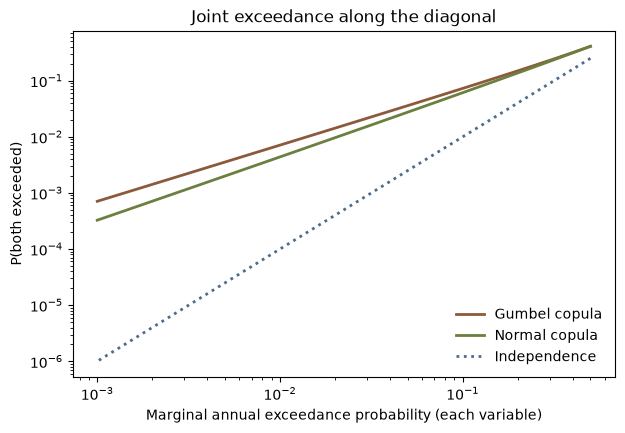

In [11]:
grid_aep = np.logspace(np.log10(0.5), np.log10(0.001), 60)
g_curve = [gumbel.exceedance(a, a, "and") for a in 1 - grid_aep]
n_curve = [normal.exceedance(a, a, "and") for a in 1 - grid_aep]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid_aep, g_curve, lw=2, color="#8c5a3b", label="Gumbel copula")
ax.plot(grid_aep, n_curve, lw=2, color="#6b7f3f", label="Normal copula")
ax.plot(grid_aep, grid_aep**2, lw=2, ls=":", color="#4d6b8a", label="Independence")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Marginal annual exceedance probability (each variable)")
ax.set_ylabel("P(both exceeded)")
ax.set_title("Joint exceedance along the diagonal")
ax.legend(frameon=False, loc="lower right")
plt.show()

## The Normal copula is the bivariate lognormal

A Normal copula with lognormal marginals is a bivariate normal in log space, so the same joint
probability is available from `mvdist_normal()` as a rectangle probability.
`MultivariateDistribution.interval()` returns `P(lower <= X <= upper)` through the ported Genz
algorithm, and the two routes have to agree.

In [12]:
px = normal.margin_x.params
py = normal.margin_y.params
rho = normal.theta
covar = [
    [px[1] ** 2, rho * px[1] * py[1]],
    [rho * px[1] * py[1], py[1] ** 2],
]

mvn = ch.mvdist_normal(mean=[px[0], py[0]], covariance=covar, seed=20250812)
rect = mvn.interval([np.log10(q_peak), np.log10(q_vol)], [1e6, 1e6])
p_norm_copula = normal.exceedance(u, v, "and")

print(f"Normal copula   {p_norm_copula:.15f}")
print(f"MVN rectangle   {rect:.15f}")
print(f"relative difference {rect / p_norm_copula - 1:.1e}")

Normal copula   0.085332736299363
MVN rectangle   0.085332736299362
relative difference -1.1e-14


`mvdist_normal()` takes a `seed` because the Genz integrator draws from a per-instance Mersenne
Twister. Leave it out and the instance is clock-seeded, so any value that depends on those draws
stops being reproducible run to run, let alone across languages.
`MultivariateDistribution.cdf()` avoids the integrator entirely at dimension one and two, where
the ported code uses closed forms.

The same object answers the conditional question directly.

In [13]:
cond = mvn.conditional(given=1, values=np.log10(q_peak))
cond_mean = float(cond.mean()[0])
cond_sd = float(np.sqrt(cond.covariance()[0][0]))
p_cond = 1 - ch.Distribution("Normal", [cond_mean, cond_sd]).cdf(np.log10(q_vol))

print(f"log10 volume given a 20,000 cfs peak: mean {cond_mean:.4f}, sd {cond_sd:.4f}")
print(f"P(volume > 12 kaf | peak = 20,000 cfs) = {p_cond:.4f}")

log10 volume given a 20,000 cfs peak: mean 1.1052, sd 0.0906
P(volume > 12 kaf | peak = 20,000 cfs) = 0.6129


`MultivariateDistribution.marginal()`, `.conditional()`, and `.interval()` are
`MultivariateNormal` methods only; `MultivariateStudentT` has no upstream counterpart for any of
the three.

## Cross-check against the model path

`bivariate_analysis()` reaches the same copula from the other direction. It wraps the two fixed
marginals and the copula in a model, estimates the dependence parameter with a Bayesian MCMC, and
returns a credible band alongside the point curve.

In [14]:
grid_x = [15000, 20000, 25000]
grid_y = [9, 12, 15]

ba = ch.bivariate_analysis(
    "LogNormal", peak, px, "LogNormal", volume, py,
    xy_x=grid_x, xy_y=grid_y, copula="Normal",
    estimation_method="InferenceFromMargins", sampler="DEMCz",
    iterations=1000, output_length=4000, seed=20250812,
    number_of_chains=4, thinning_interval=1,
)

map_copula = ch.Copula("Normal", ba["parameters"][0])
gu = [normal.margin_x.cdf(x) for x in grid_x]
gv = [normal.margin_y.cdf(y) for y in grid_y]
at_map = [map_copula.exceedance(a, b, "and") for a, b in zip(gu, gv)]

cross = pd.DataFrame({
    "peak": grid_x, "volume": grid_y,
    "analysis_curve": ba["mode_curve"],
    "analysis_lower": ba["lower_ci"], "analysis_upper": ba["upper_ci"],
    "copula_at_map": at_map,
})
print(cross.round(5))
print(f"theta: {normal.theta:.6f} from copula_fit(ifm), "
      f"{ba['parameters'][0]:.6f} reported by the analysis")

    peak  volume  analysis_curve  analysis_lower  analysis_upper  \
0  15000       9         0.24999         0.23741         0.26039   
1  20000      12         0.08362         0.07596         0.09025   
2  25000      15         0.02658         0.02305         0.02977   

   copula_at_map  
0        0.25272  
1        0.08533  
2        0.02739  
theta: 0.842690 from copula_fit(ifm), 0.842682 reported by the analysis


The two paths agree on the dependence parameter to four decimal places, and the copula verb's
probability sits inside the analysis's own credible band at all three ordinates. They are not
identical, and the reason is worth knowing: `bivariate_analysis()` reports the posterior maximum
in `parameters`, but builds its curve at whatever point estimator the underlying Bayesian
analysis carries, which defaults to the posterior mean. Evaluating `Copula.exceedance()` at the
reported maximum therefore answers a slightly different question than the curve does.

## Reproduction check

In [15]:
# Every fit on this page is deterministic (the copula estimators are optimizers over a fixed
# sample; the Bayesian cross-check is seeded), so these literals are what this port computes --
# and the R version asserts exactly the same ones, which is what proves the cross-language
# identity. Both packages run the same compiled core with a bit-exact Mersenne Twister, so the
# match is exact here rather than merely close.

# Maximum pseudo-likelihood across five families.
assert mpl["Clayton"].theta == 2.306331361987462
assert mpl["Frank"].theta == 8.671632193669629
assert mpl["Gumbel"].theta == 2.8147142423362927
assert mpl["Joe"].theta == 3.552224446549273
assert mpl["Normal"].theta == 0.8652104567754928
assert ranking.loc["Normal", "pseudo_loglik"] == 30.37021026264206
assert ranking.loc["Gumbel", "pseudo_loglik"] == 30.043841011715617

# Kendall's tau inversion.
assert ch.copula_fit("Clayton", peak, volume, method="tau").theta == 3.4473182880894253
assert ch.copula_fit("Gumbel", peak, volume, method="tau").theta == 2.7236591440447127

# Inference from margins: the marginals and the two copulas.
assert list(gumbel.margin_x.params) == [4.067428305746908, 0.18679432530177564]
assert list(gumbel.margin_y.params) == [0.9277617491331209, 0.16835824505465125]
assert gumbel.theta == 2.7122936851673694
assert normal.theta == 0.8426897364136787
assert cmp.loc["Gumbel", "ifm_loglik"] == 29.900498224775983
assert cmp.loc["Normal", "ifm_loglik"] == 29.718349666163725

# Tail dependence.
assert gumbel.tail_dependence() == {"lower": 0.0, "upper": 0.7088186571198125}
assert normal.tail_dependence() == {"lower": 0.0, "upper": 0.0}

# The coincident design event.
assert u == 0.8944565568493446
assert v == 0.8157771621304127
assert joint.loc["Gumbel copula", "p_and"] == 0.09432008642998968
assert joint.loc["Normal copula", "p_and"] == 0.08533273629936333
assert joint.loc["Independence", "p_and"] == 0.019443512615741197
assert gumbel.exceedance(u, v, "or") == 0.19544619459025303

# The joint corner: both marginals held at the same exceedance probability.
assert corner["gumbel"][1] == 0.07280812787407953
assert corner["normal"][1] == 0.06108589721330093
assert corner["gumbel"][4] == 0.001418389605702286
assert corner["normal"][4] == 0.0007117005346523042
assert corner["gumbel_over_normal"][0] == 1.0915335165887639
assert corner["gumbel_over_normal"][4] == 1.9929584658738935

# The bivariate-normal route to the same probability.
assert rect == 0.08533273629936243
assert cond_mean == 1.1051865785007626
assert cond_sd == 0.0906439928542586
assert p_cond == 0.6129037423608137

# The seeded bivariate_analysis() cross-check.
assert ba["parameters"][0] == 0.8426821280648094
assert ba["mode_curve"][1] == 0.08361846558111918
assert ba["lower_ci"][1] == 0.07596283077502097
assert ba["upper_ci"][1] == 0.09024669661223572
assert at_map[1] == 0.08533174883673333

# Internal consistency: the and-joint identity the core computes, the ordering of the three
# joint-probability answers, and the copula verb landing inside the analysis's credible band.
assert abs(normal.exceedance(u, v, "and") - (1 - u - v + normal.cdf(u, v))) < 1e-15
assert abs(rect / p_norm_copula - 1) < 1e-12
assert joint.loc["Gumbel copula", "p_and"] > joint.loc["Normal copula", "p_and"]
assert joint.loc["Normal copula", "p_and"] > joint.loc["Independence", "p_and"]
assert (np.diff(corner["gumbel_over_normal"]) > 0).all()
assert (corner["gumbel"] > corner["normal"]).all()
assert (corner["normal"] > corner["independence"]).all()
assert (np.asarray(at_map) > np.asarray(ba["lower_ci"])).all()
assert (np.asarray(at_map) < np.asarray(ba["upper_ci"])).all()
assert (np.diff(ba["mode_curve"]) < 0).all()

print("All reproduction checks passed.")

All reproduction checks passed.
